In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
merchants_df = pd.read_excel('dataset/dstakehome_merchants.xlsx')
payments_df = pd.read_excel('dataset/dstakehome_payments.xlsx')


In [5]:
#['date', 'merchant', 'subscription_volume', 'checkout_volume', 'payment_link_volume', 'total_volume']
payment_columns = payments_df.columns.tolist() 
# ['merchant', 'industry', 'first_charge_date', 'country', 'business_size']
merchant_columns = merchants_df.columns.tolist()


payments_df['merchant'] = payments_df['merchant'].astype(str)
merchants_df['merchant'] = merchants_df['merchant'].astype(str)

# Cleaning stage

In [6]:
def unify_test_dates(df, date_col='date'):

    from dateutil import parser

    def parse_date(val):
        # Try several custom parsing rules
        if pd.isnull(val):
            return pd.NaT
        try:
            # Try ISO 8601 with optional 'T' and 'Z', e.g., 2042-06-22T00:00:00Z
            return pd.to_datetime(val, format="%Y-%m-%dT%H:%M:%SZ", errors='raise', utc=True)
        except Exception:
            pass
        try:
            # Try classic ISO format first
            return pd.to_datetime(val, format="%Y-%m-%d", errors='raise')
        except Exception:
            pass
        try:
            # Try common "day-mon-year" format
            return pd.to_datetime(val, format="%d-%b-%y", errors='raise')
        except Exception:
            pass
        try:
            # Try "day-mon-year hour:min:sec"
            return pd.to_datetime(val, format="%d-%b-%y %H:%M:%S", errors='raise')
        except Exception:
            pass
        try:
            # Use dateutil parser as a fallback (very permissive)
            return parser.parse(str(val), dayfirst=True, fuzzy=True)
        except Exception:
            return pd.NaT

    df[date_col] = df[date_col].apply(parse_date)
    return df

payments_df_clean = unify_test_dates(payments_df, 'date')
merchants_df_clean = unify_test_dates(merchants_df, 'first_charge_date')
total_df = payments_df_clean.copy()
total_df = total_df.merge(merchants_df_clean, on='merchant', how='left')
total_df.drop(['first_charge_date', 'country'], axis=1, inplace=True)
total_df = total_df[total_df['merchant'] != '0']

In [7]:
# Calculate the subscription ratio for each merchant (total_subscription_volume / total_volume)
subscription_ratio_df = (
    total_df.groupby("merchant")[["subscription_volume", "total_volume"]]
    .sum()
    .assign(
        subscription_ratio=lambda df: df["subscription_volume"] / df["total_volume"].replace(0, np.nan)
    )
    .sort_values("subscription_ratio", ascending=False)
)
cv_df = (
    total_df.groupby("merchant")[["total_volume"]]
    .agg(['mean', 'std'])
)
cv_df.columns = ['mean_total_volume', 'std_total_volume']
cv_df['cv_total_volume'] = cv_df['std_total_volume'] / cv_df['mean_total_volume'].replace(0, np.nan)
cv_df = cv_df.sort_values("cv_total_volume", ascending=False)

subscription_ratio_df.rename(columns={'subscription_volume': 'sub_cap', 'total_volume': 'total_cap'}, inplace=True)
subscription_ratio_df.reset_index(inplace=True)

total_df = total_df.merge(subscription_ratio_df, on='merchant', how='left')
total_df = total_df.merge(cv_df, on='merchant', how='left')


In [8]:
sub_merchants = total_df[total_df['subscription_ratio'] > 0.8]['merchant'].unique()
total_merchants = total_df['merchant'].unique()
print("merchants who the subscription ratio is greater than 0.8: ",len(sub_merchants) / len(total_merchants))

merchants who the subscription ratio is greater than 0.8:  0.10533892205427833


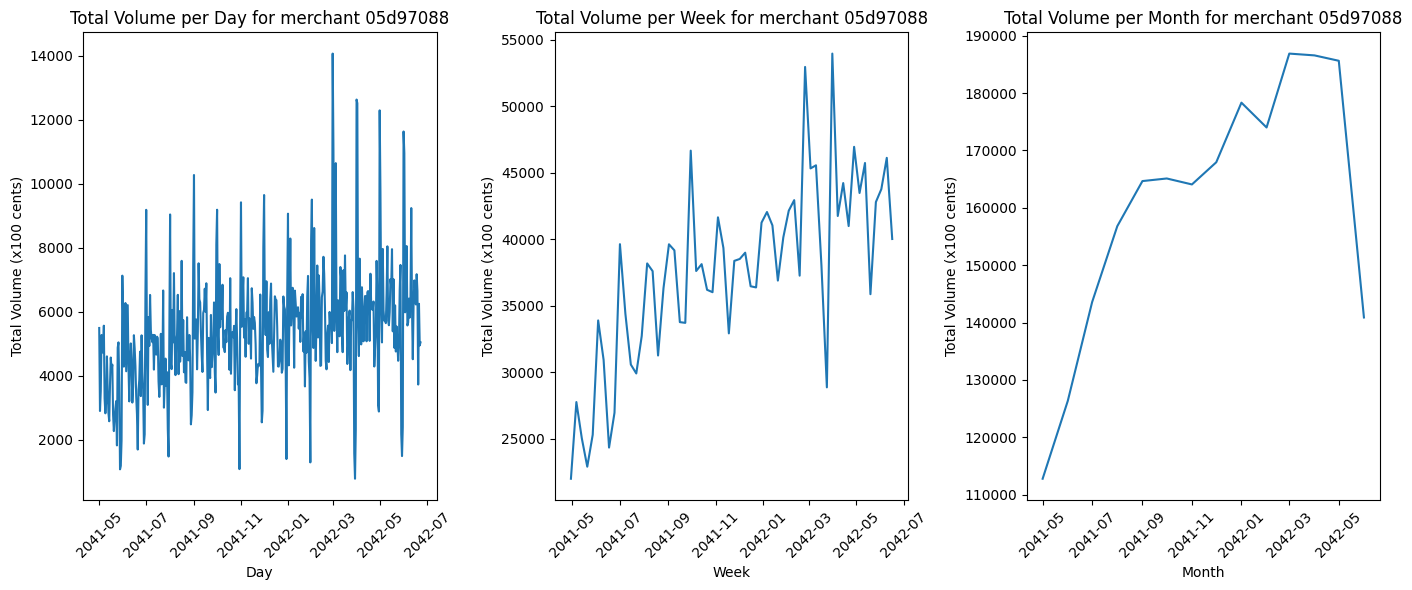

In [9]:
import matplotlib.pyplot as plt
import warnings
merchant_id = '05d97088'
store_df = total_df[total_df['merchant'] == merchant_id].copy()
store_df = store_df.sort_values('date')
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=UserWarning)
    store_df['week'] = store_df['date'].dt.to_period('W').apply(lambda r: r.start_time)
    store_df['day'] = store_df['date'].dt.to_period('D').apply(lambda r: r.start_time)
    store_df['month'] = store_df['date'].dt.to_period('M').apply(lambda r: r.start_time)

fig, axs = plt.subplots(1, 3, figsize=(14, 6), sharex=False)

# Day plot
axs[0].plot(store_df.groupby('day')['total_volume'].sum() / 100)
axs[0].set_xlabel("Day")
axs[0].set_ylabel("Total Volume (x100 cents)")
axs[0].set_title(f"Total Volume per Day for merchant {merchant_id}")
axs[0].tick_params(axis='x', rotation=45)

# Week plot
axs[1].plot(store_df.groupby('week')['total_volume'].sum() / 100)
axs[1].set_xlabel("Week")
axs[1].set_ylabel("Total Volume (x100 cents)")
axs[1].set_title(f"Total Volume per Week for merchant {merchant_id}")
axs[1].tick_params(axis='x', rotation=45)

# Month plot
axs[2].plot(store_df.groupby('month')['total_volume'].sum() / 100)
axs[2].set_xlabel("Month")
axs[2].set_ylabel("Total Volume (x100 cents)")
axs[2].set_title(f"Total Volume per Month for merchant {merchant_id}")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

05d97088


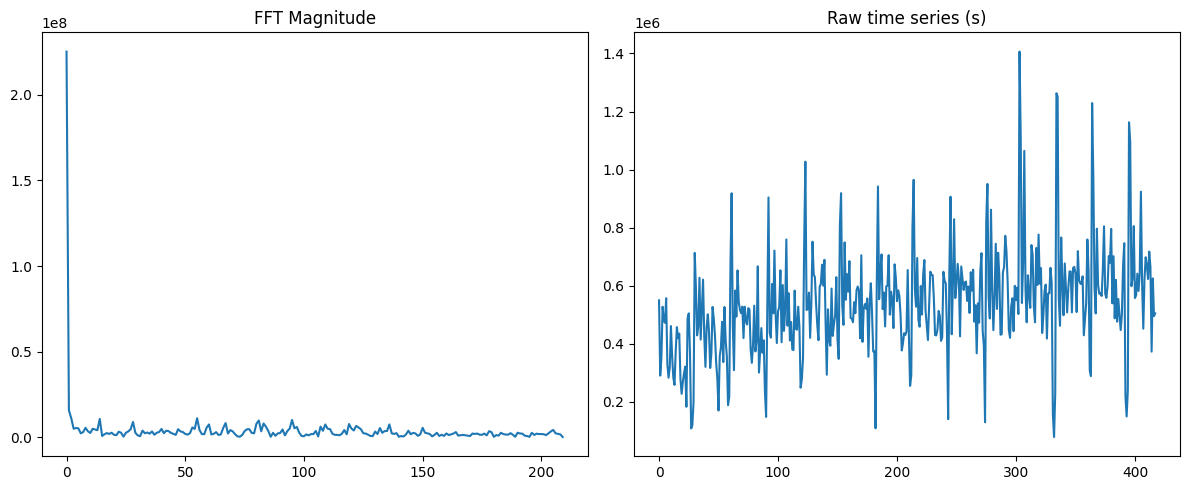

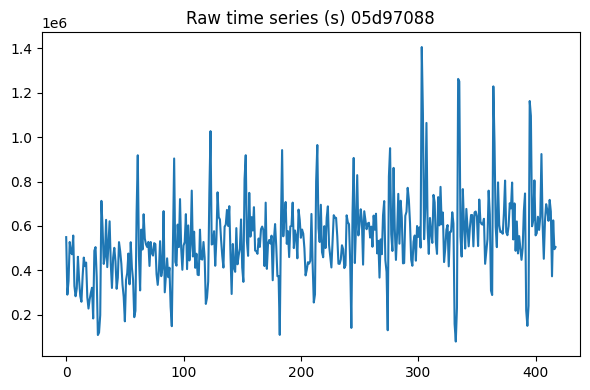

active_ratio                              1.0
weekly_autocorr                      0.178066
biweekly_autocorr                    0.203777
monthly_autocorr                     0.327833
avg_gap_between_payments                  1.0
gap_regularity_share_7d                   0.0
gap_regularity_share_30d                  0.0
gaps_std                                  0.0
weekday_entropy                      1.945881
cv_volume                            0.333733
cv_weekly                            0.182943
cv_monthly                           0.141494
burstiness                           -0.49955
industry_boost                            1.0
volume_scale                             10.0
total_volume                        225362280
subscription_ratio                        0.0
checkout_ratio                            0.0
payment_link_ratio                        0.0
business_size                           small
industry                    Business services
dtype: object

In [12]:
def clamp01(x: float) -> float:
    if pd.isna(x):
        return 0.0
    return float(max(0.0, min(1.0, x)))

def coef_var(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    if len(x) == 1:
        # Warn or quietly return np.nan if only 1 value (prevents degrees of freedom <= 0)
        return np.nan
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=1))  # Use unbiased estimator (N-1); avoid ddof=0 warning if only one value
    if np.isclose(mu, 0):
        # Prevent divide by zero, emit a clearer NaN
        return np.nan
    return float(sd / mu)

def gap_regularity_share(days: pd.Series, target_gap: int, tol: int = 1) -> float:
    """Share of inter-payment gaps close to a target cadence (e.g. 7 or 30 days)."""
    if len(days) < 6:
        return np.nan
    d = pd.to_datetime(days).sort_values().dropna()
    gaps = d.diff().dt.days.dropna().to_numpy()
    if len(gaps) == 0:
        return np.nan
    return float(np.mean(np.abs(gaps - target_gap) <= tol))

def merchant_recurring_features(group, date_col='date', value_col='total_volume', verbose=False):
    # 1. Sort and prepare
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    s = group[value_col].asfreq('D', fill_value=0)
    # 3. Basic signals
    total_days = len(s)
    active_days = (s > 0).sum()
    active_ratio = active_days / total_days if total_days > 0 else np.nan

    # 4. Autocorrelation (weekly + monthly patterns)
    def safe_autocorr(series, lag):
        if len(series) <= lag or series.nunique() <= 1:
            return np.nan
        return series.autocorr(lag=lag)

    weekly_autocorr = safe_autocorr(s, lag=7)
    biweekly_autocorr = safe_autocorr(s, lag=14)
    monthly_autocorr = safe_autocorr(s, lag=30)

    # 5. Occurrence pattern (how often payments happen)
    avg_gap = np.nan
    payment_days = s[s > 0].index
    gaps_std = np.nan
    if len(payment_days) > 1:
        gaps = np.diff(payment_days.values).astype('timedelta64[D]').astype(int)
        if len(gaps) > 0:
            avg_gap = gaps.mean()
        else:
            avg_gap = np.nan
        gaps_std = np.std(gaps) if len(gaps) > 1 else np.nan


    mean_val = s.mean()
    std_val = s.std(ddof=1) if len(s) > 1 else np.nan  # ddof=1 for unbiased; nan for single value

    # Prevent divide by zero (and thus suppress RuntimeWarning)
    if np.isclose(mean_val, 0):
        cv = np.nan
    else:
        cv = std_val / mean_val  # coefficient of variation

    total_volume_sum = group['total_volume'].sum()
    subscription_volume_sum = group['subscription_volume'].sum()
    checkout_volume_sum = group['checkout_volume'].sum()
    payment_link_volume_sum = group['payment_link_volume'].sum()

    # Prevent division by zero by checking if total_volume_sum is "close to zero"
    if np.isclose(total_volume_sum, 0):
        subscription_ratio = np.nan
        checkout_ratio = np.nan
        payment_link_ratio = np.nan
    else:
        subscription_ratio = subscription_volume_sum / total_volume_sum
        checkout_ratio = checkout_volume_sum / total_volume_sum
        payment_link_ratio = payment_link_volume_sum / total_volume_sum

    weekly_totals = group['total_volume'].resample('W').sum().to_numpy(dtype=float)
    # Suppress warning by checking length
    # Also prevent divide by zero inside coef_var
    nonzero_weekly = weekly_totals[~np.isclose(weekly_totals, 0)]
    if len(nonzero_weekly) > 1:
        weekly_cv = coef_var(nonzero_weekly)
    else:
        weekly_cv = np.nan

    # FIX: Use correct monthly frequency string ('M'), not 'ME'!
    monthly_totals = group['total_volume'].resample('M').sum().to_numpy(dtype=float)
    nonzero_monthly = monthly_totals[~np.isclose(monthly_totals, 0)]
    if len(nonzero_monthly) > 1:
        monthly_cv = coef_var(nonzero_monthly)
    else:
        monthly_cv = np.nan

    industry = str(group['industry'].iloc[0]).lower()

    if industry:
        if any(k in industry for k in ['software', 'education', 'membership', 'religion', 'fitness', 'health', 'business services', 'leisure']):
            industry_boost = 1.0
        elif any(k in industry for k in ['retail', 'restaurant', 'food', 'travel', 'events']):
            industry_boost = 0.3
        else:
            industry_boost = 0.0
    else:
        industry_boost = 0.0  # ensure defined

    # Size sanity: avoid tiny merchants dominating by perfect regularity
    tot = total_volume_sum
    # Prevent log of zero/negative. (1+tot) always nonzero/positive as tot>=0
    size = clamp01(np.log10(1 + tot) / np.log10(1 + 10e7))  # 10e6 cents = $1M
    # print(np.log10(1 + tot) / np.log10(1 + 10e6))
    volume_scale = 10 * size

    # entropy of weekday distribution
    weekday_counts = s[s > 0].index.weekday
    weekday_entropy = -np.sum(np.bincount(weekday_counts, minlength=7) / len(weekday_counts)
    * np.log(np.bincount(weekday_counts, minlength=7) / len(weekday_counts) + 1e-9))

    nonzero_days = s[s > 0]
    if len(nonzero_days) > 1:
        burstiness = (nonzero_days.std() - nonzero_days.mean()) / (nonzero_days.std() + nonzero_days.mean())
    else:
        burstiness = np.nan

    if verbose:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        axs[0].plot(np.abs(np.fft.rfft(s)))
        axs[0].set_title("FFT Magnitude")
        axs[1].plot(s.values)
        axs[1].set_title("Raw time series (s)")
        plt.tight_layout()
        plt.show()

    if verbose:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 1, figsize=(6, 4))
        axs.plot(s.values)
        axs.set_title(f"Raw time series (s) {merchant_id}")
        plt.tight_layout()
        plt.savefig(f"raw_time_series_{merchant_id}.pdf")
        plt.show()

    return pd.Series({
        'active_ratio': active_ratio,
        'weekly_autocorr': weekly_autocorr,
        'biweekly_autocorr': biweekly_autocorr,
        'monthly_autocorr': monthly_autocorr,
        'avg_gap_between_payments': avg_gap,
        'gap_regularity_share_7d': gap_regularity_share(group.reset_index()['date'], 7),
        'gap_regularity_share_30d': gap_regularity_share(group.reset_index()['date'], 30),
        'gaps_std': gaps_std,
        'weekday_entropy': weekday_entropy,
        'cv_volume': cv,
        'cv_weekly': weekly_cv,
        'cv_monthly': monthly_cv,
        'burstiness': burstiness,
        'industry_boost': industry_boost,
        'volume_scale': volume_scale,
        'total_volume': total_volume_sum,
        'subscription_ratio': subscription_ratio,
        'checkout_ratio': checkout_ratio,
        'payment_link_ratio': payment_link_ratio,
        'business_size': group['business_size'].iloc[0],
        'industry': group['industry'].iloc[0]
    })

for merchant_id, group in total_df.groupby('merchant'):
    if merchant_id == '05d97088':
        print(merchant_id)
        a = merchant_recurring_features(group, value_col='total_volume', verbose=True)
        display(a)
        break

In [13]:
# Extract features for each merchant and construct a DataFrame with merchants as rows and features as columns
feature_extracted_list = []
merchant_ids = []
for merchant_id, group in total_df.groupby('merchant'):
    # print(merchant_id)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        features = merchant_recurring_features(group, value_col='total_volume')
        feature_extracted_list.append(features)
        merchant_ids.append(merchant_id)

feature_extracted = pd.DataFrame(feature_extracted_list, index=merchant_ids)

In [14]:
feature_extracted.fillna(0, inplace=True)
# high subscription merchants records
# after computing all merchant features

good = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]

centroid = good.mean(numeric_only=True)

from sklearn.metrics.pairwise import cosine_similarity

X = feature_extracted.select_dtypes(include=[np.number]).fillna(0)

feature_extracted['similarity_to_good'] = cosine_similarity(
    X, centroid.values.reshape(1, -1)
).flatten()

# COSINE based annotating 

In [15]:

from sklearn.metrics.pairwise import cosine_similarity
sub_features = feature_extracted[feature_extracted['subscription_ratio'] > 0.9]
non_sub_features = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]


# Choose feature columns to use for similarity (exclude business_size, industry, and possibly any other categorical)
exclude_cols = ['business_size', 'industry']
feature_cols = [col for col in sub_features.columns if col not in exclude_cols]

sub_vecs = sub_features[feature_cols].values
sub_vecs = np.nan_to_num(sub_vecs, nan=0)

non_sub_vecs = non_sub_features[feature_cols].values
non_sub_vecs = np.nan_to_num(non_sub_vecs, nan=0)

# Compute similarity of each non_subscription merchant to the average feature vector of sub_features
sub_mean_vec = sub_vecs.mean(axis=0, keepdims=True)
cos_sim = cosine_similarity(non_sub_vecs, sub_mean_vec).flatten()

# Attach similarity scores back to the non_sub_features DataFrame
non_sub_features_sim = non_sub_features.copy()
non_sub_features_sim['sim_to_sub'] = cos_sim

# Find top candidates
top_candidates = non_sub_features_sim.sort_values('sim_to_sub', ascending=False).head(10)
top_candidates

,active_ratio,weekly_autocorr,biweekly_autocorr,monthly_autocorr,avg_gap_between_payments,gap_regularity_share_7d,gap_regularity_share_30d,gaps_std,weekday_entropy,cv_volume,...,industry_boost,volume_scale,total_volume,subscription_ratio,checkout_ratio,payment_link_ratio,business_size,industry,similarity_to_good,sim_to_sub
9a06d9c2,0.039216,-0.030198,0.090230,-0.030722,27.133333,0.066667,0.066667,16.732669,1.494175,5.681113,...,1.0,9.226168,24040000,0.000000,0.0,0.00000,small,Software,1.0,1.0
e76ffd89,0.070707,-0.025396,0.122937,-0.034324,15.153846,0.000000,0.000000,9.686201,1.296361,5.396529,...,0.0,8.907884,13375415,0.000000,0.0,1.00000,small,Construction,1.0,1.0
34288d6d,0.051020,-0.003223,-0.041076,-0.013307,20.578947,0.157895,0.052632,14.726688,1.544480,4.931260,...,0.3,9.047753,17306225,0.000000,0.0,0.00000,medium,Grocery & food stores,1.0,1.0
f1f9a7d3,0.046448,0.056923,-0.035768,0.074664,22.812500,0.250000,0.250000,9.773809,1.641845,5.777314,...,1.0,8.972342,15061697,0.000000,0.0,0.00000,small,Business services,1.0,1.0
fcb72eec,0.067647,-0.036047,0.080814,0.090786,15.409091,0.045455,0.045455,10.298540,1.376090,4.196009,...,1.0,8.867425,12414800,0.000000,0.0,0.00000,small,Business services,1.0,1.0
11cdde01,0.100000,0.046463,-0.076391,0.015049,10.692308,0.384615,0.000000,4.873549,1.400327,3.525461,...,0.3,8.724306,9537726,0.000000,0.0,0.00000,small,Grocery & food stores,1.0,1.0
4b4cfdb7,0.085000,-0.062727,-0.047214,0.231000,12.090909,0.030303,0.030303,8.589506,1.764877,3.990305,...,1.0,8.993663,15665000,0.006384,0.0,0.00000,small,Business services,1.0,1.0
fbc7ee45,0.061069,0.030671,-0.036752,-0.021231,17.043478,0.217391,0.000000,13.297526,1.592657,5.003490,...,1.0,8.952347,14517018,0.000000,0.0,0.00000,small,Business services,1.0,1.0
6ffe668f,0.022222,-0.009435,-0.009986,-0.011526,67.000000,0.000000,0.000000,10.000000,0.636514,9.725227,...,1.0,9.569891,45280699,0.000000,0.0,0.17784,small,Business services,1.0,1.0
71266d1c,0.096203,-0.031491,0.112018,0.095097,10.648649,0.162162,0.027027,7.159255,1.484566,3.219081,...,1.0,8.949835,14450006,0.000000,0.0,0.00000,small,Business services,1.0,1.0


In [16]:

time_series_output = []
merchant_id_list = []
def time_series_df(group,min_date,max_date, date_col='date', value_col='total_volume'):
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    group = group.set_index(date_col)
    # 2. Create consecutive daily time series
    full_range = pd.date_range(start=min_date, end=max_date, freq='D')
    s = group.reindex(full_range)[value_col].fillna(0)
    s.index = full_range
    # INSERT_YOUR_CODE
    s_min = s.min()
    s_max = s.max()
    if s_max > s_min:
        s = (s - s_min) / (s_max - s_min)
    else:
        s = s * 0  # if all values are the same, set to 0
    return s.tolist()


min_date = total_df['date'].min()
max_date = total_df['date'].max()
for merchant_id, group in total_df.groupby('merchant'):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        ts = time_series_df(group,min_date,max_date)
        time_series_output.append(ts)
        merchant_id_list.append(merchant_id)
time_series_output = np.array(time_series_output)


In [17]:
import rocket.miniROCKET as mr
from sklearn.preprocessing import StandardScaler

time_series_output = time_series_output.astype(np.float32)
parameter = mr.fit(time_series_output,num_features=10000)
dilations, num_features_per_dilation,_, biases = parameter
parameter = dilations, num_features_per_dilation,biases

time_series_tranformed = mr.transform(time_series_output, parameter,'ter')


scaler = StandardScaler()
time_series_transformed_scaled = scaler.fit_transform(time_series_tranformed)

In [18]:
excludede_columns = ['subscription_ratio','business_size', 'industry']
feature_extracted.loc['000a45ba'].drop(excludede_columns).values.tolist()

[0.09610389610389611,
 0.07858257025690393,
 0.10293650813548987,
 -0.04889686493018578,
 10.666666666666666,
 0.1388888888888889,
 0.027777777777777776,
 15.249772311597164,
 1.832904240141466,
 3.626897965261155,
 0.9743525444552535,
 1.0588833193180909,
 -0.24552892754978847,
 0.0,
 6.442272386520708,
 142500,
 0.0,
 0.0,
 0.9999999901502687]

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier

merchant_id_list = feature_extracted.index.tolist()
good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index':'merchant'})['merchant'].tolist()
good_sub_merchant_indices = [merchant_id_list.index(m) for m in good_sub_merchant if m in merchant_id_list]
# Here's an improved and bug-annotated rewrite:
good_sub_merchant = feature_extracted[feature_extracted['subscription_ratio'] > 0.7].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()
unknown_merchant = feature_extracted[feature_extracted['subscription_ratio'] < 0.2].reset_index().rename(columns={'index': 'merchant'})['merchant'].tolist()

np.random.seed(None)


x_subscripted_feature = []
y_subscripted = []
m_subscripted = []

excludede_columns = ['subscription_ratio','business_size', 'industry']

for m in good_sub_merchant:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_subscripted.append(m)
    # x_subscripted_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_subscripted_feature.append(f)
    y_subscripted.append('subscription')

x_unknown_feature = []
y_unknown = []
m_unknown = []

for m in unknown_merchant:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_unknown.append(m)
    # x_unknown_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_unknown_feature.append(f)
    y_unknown.append('non-subscription')

x_subscripted_feature = np.array(x_subscripted_feature)
y_subscripted = np.array(y_subscripted)
m_subscripted = np.array(m_subscripted)

x_unknown_feature = np.array(x_unknown_feature)
y_unknown = np.array(y_unknown)
m_unknown = np.array(m_unknown)

print('===============================================')
print('Total number of subscription merchants: ', x_subscripted_feature.shape)

print('Total number of non-subscription merchants: ', x_unknown_feature.shape)
# dataset creation

indices_sub_train = np.random.choice(range(len(x_subscripted_feature)), size=int(len(x_subscripted_feature)*0.7), replace=False)
indices_sub_test = [i for i in range(len(x_subscripted_feature)) if i not in indices_sub_train]


number_of_non_sub = min(int(len(x_subscripted_feature)*4), len(x_unknown_feature))  # Avoid overflow; don't pick more samples than possible.
indices_non_sub_train = np.random.choice(range(len(x_unknown_feature)),size=int(number_of_non_sub*0.7),replace=False)
rest_of_unknown = set(np.arange(len(x_unknown_feature))) - set(indices_non_sub_train)
# If remaining is not enough, sample with replacement (guards against ValueError)
size_for_non_sub_test = int(number_of_non_sub*0.3)
if len(rest_of_unknown) >= size_for_non_sub_test:
    indices_non_sub_test = np.random.choice(list(rest_of_unknown), size=size_for_non_sub_test, replace=False)
else:
    indices_non_sub_test = np.random.choice(range(len(x_unknown_feature)), size=size_for_non_sub_test, replace=True)

x_train = np.concatenate([x_subscripted_feature[indices_sub_train], x_unknown_feature[indices_non_sub_train]])
y_train = np.concatenate([y_subscripted[indices_sub_train], y_unknown[indices_non_sub_train]])
m_train = np.concatenate([m_subscripted[indices_sub_train], m_unknown[indices_non_sub_train]])

x_test = np.concatenate([x_subscripted_feature[indices_sub_test], x_unknown_feature[indices_non_sub_test]])
y_test = np.concatenate([y_subscripted[indices_sub_test], y_unknown[indices_non_sub_test]])
m_test = np.concatenate([m_subscripted[indices_sub_test], m_unknown[indices_non_sub_test]])


print('X_test shape: ',x_test.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_train shape: ', x_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape: ', x_test.shape)
print('y_test shape: ', y_test.shape)

#scaling 
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

ridge_classifier = RidgeClassifier(alpha=1, class_weight='balanced')
ridge_classifier.fit(x_train, y_train)


Total number of subscription merchants:  (2675, 19)
Total number of non-subscription merchants:  (19979, 19)
X_test shape:  (4013, 19)
X_train shape:  (9361, 19)
y_train shape:  (9361,)
X_train shape:  (9361, 19)
y_train shape:  (9361,)
X_test shape:  (4013, 19)
y_test shape:  (4013,)


/home/akeshavarzian/stripe-recurrence-score/.venv/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=7.0465e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


RidgeClassifier(alpha=1, class_weight='balanced')

Accuracy test:  0.791926239720907 Accuracy train:  0.7939322721931418


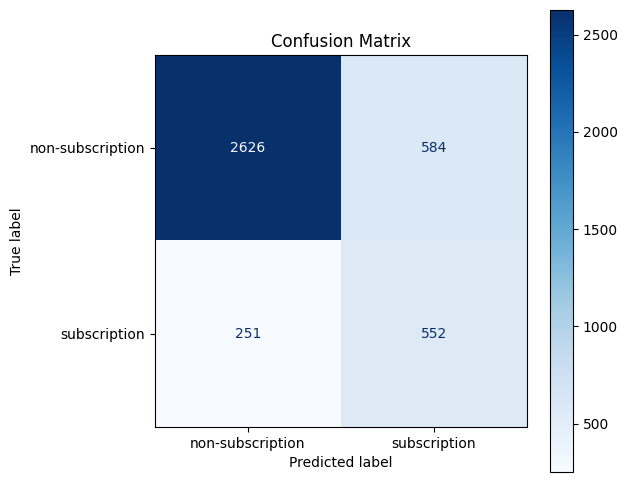

In [20]:
accuracy_test, accuracy_train = ridge_classifier.score(x_test, y_test), ridge_classifier.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = ridge_classifier.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=ridge_classifier.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

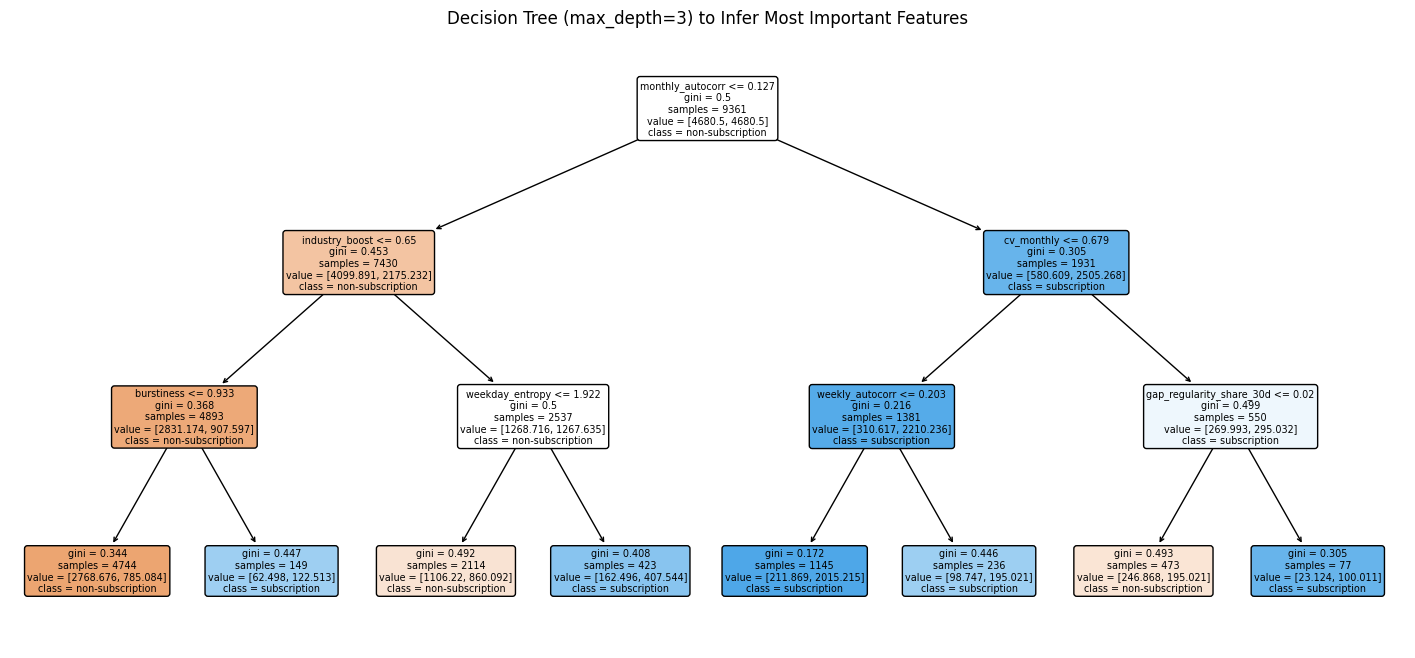

Accuracy test:  0.8203339147769748 Accuracy train:  0.8258733041341737
Feature importances (descending):
Feature monthly_autocorr: Importance = 0.6376
Feature industry_boost: Importance = 0.1422
Feature cv_monthly: Importance = 0.0827
Feature burstiness: Importance = 0.0488
Feature weekday_entropy: Importance = 0.0485
Feature weekly_autocorr: Importance = 0.0215
Feature gap_regularity_share_30d: Importance = 0.0189
Feature similarity_to_good: Importance = 0.0000
Feature biweekly_autocorr: Importance = 0.0000
Feature avg_gap_between_payments: Importance = 0.0000
Feature gap_regularity_share_7d: Importance = 0.0000
Feature cv_volume: Importance = 0.0000
Feature gaps_std: Importance = 0.0000
Feature payment_link_ratio: Importance = 0.0000
Feature cv_weekly: Importance = 0.0000
Feature volume_scale: Importance = 0.0000
Feature total_volume: Importance = 0.0000
Feature checkout_ratio: Importance = 0.0000
Feature active_ratio: Importance = 0.0000


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# Train a decision tree classifier on the training data
dtree = DecisionTreeClassifier(max_depth=3, random_state=None, class_weight='balanced')
dtree.fit(x_train, y_train)

# Plot the decision tree to visualize feature importance and splits
features_name = feature_extracted.drop(columns=excludede_columns).columns.tolist()
plt.figure(figsize=(18, 8))
plot_tree(dtree, 
          feature_names=features_name, 
          class_names=[str(c) for c in dtree.classes_], 
          filled=True, 

          rounded=True)
plt.title("Decision Tree (max_depth=3) to Infer Most Important Features")
plt.show()

pred = dtree.predict(x_test)
accuracy_test, accuracy_train = dtree.score(x_test, y_test), dtree.score(x_train, y_train)
print('Accuracy test: ',accuracy_test, 'Accuracy train: ',accuracy_train)
# Print feature importances
importances = dtree.feature_importances_
sorted_indices = np.argsort(importances)[::-1]
print("Feature importances (descending):")
for idx in sorted_indices:
    print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

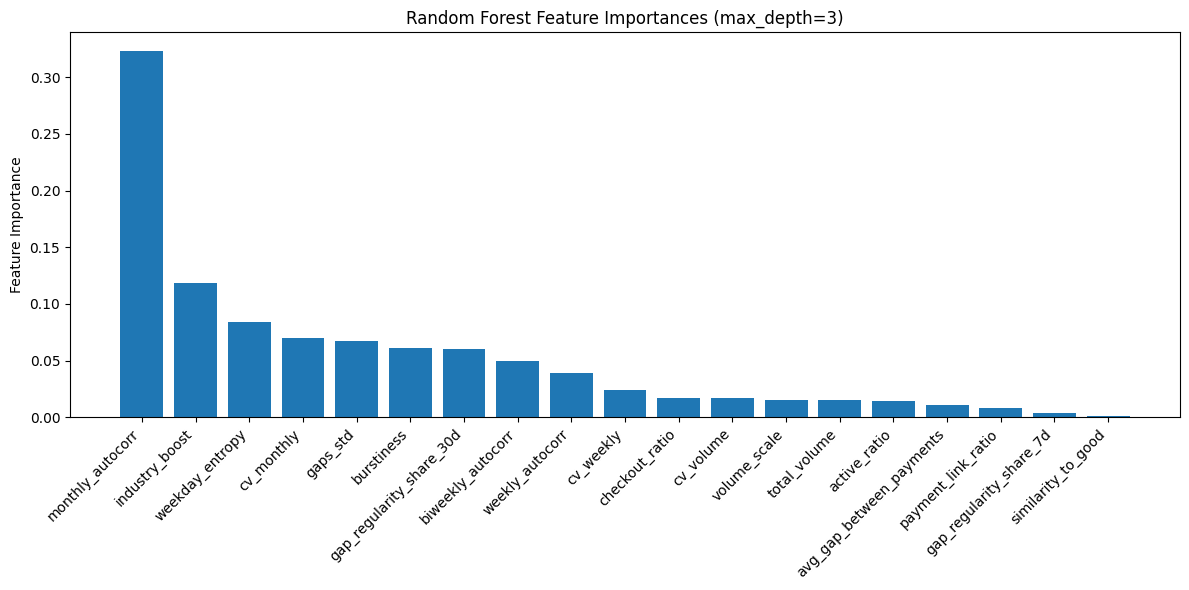

Accuracy test:  0.7896835285322701 Accuracy train:  0.8130541608802478
Feature importances (descending):


In [22]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a random forest classifier on the training data
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=None, class_weight={'subscription':5, 'non-subscription':1})
rf.fit(x_train, y_train)

# Feature names for plotting/importances
features_name = feature_extracted.drop(columns=excludede_columns).columns.tolist()

# Plot feature importances
importances = rf.feature_importances_
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(features_name)), importances[sorted_indices], align='center')
plt.xticks(range(len(features_name)), [features_name[i] for i in sorted_indices], rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances (max_depth=3)')
plt.tight_layout()
plt.savefig('random_forest_feature_importances.pdf')
plt.show()

# Predict and print accuracies
pred = rf.predict(x_test )
accuracy_test = rf.score(x_test, y_test)
accuracy_train = rf.score(x_train, y_train)
print('Accuracy test: ', accuracy_test, 'Accuracy train: ', accuracy_train)

# Print feature importances sorted
print("Feature importances (descending):")
# for idx in sorted_indices:
#     print(f"Feature {features_name[idx]}: Importance = {importances[idx]:.4f}")

<Figure size 600x600 with 0 Axes>

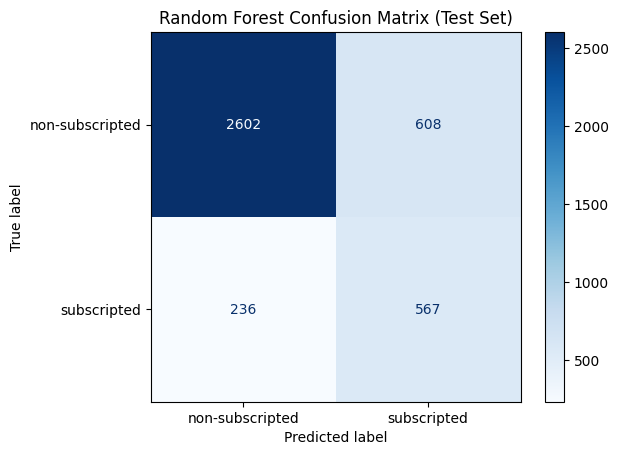

Classification Report (Test Set):
                  precision    recall  f1-score   support

non-subscription      0.917     0.811     0.860      3210
    subscription      0.483     0.706     0.573       803

        accuracy                          0.790      4013
       macro avg      0.700     0.758     0.717      4013
    weighted avg      0.830     0.790     0.803      4013



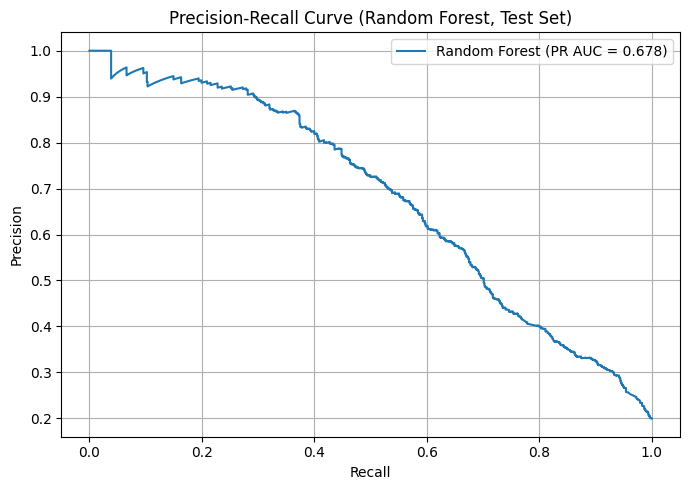

Precision-Recall AUC (Random Forest, Test Set): 0.678


In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predict the classes on the test set
y_pred_rf = rf.predict(x_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
# Define the display labels as requested
labels = [ 'non-subscripted', 'subscripted']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Random Forest Confusion Matrix (Test Set)')
plt.savefig('random_forest_confusion_matrix.pdf')
plt.show()
from sklearn.metrics import classification_report

# Generate and display the classification report for the Random Forest classifier
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_rf, digits=3))

from sklearn.metrics import precision_recall_curve, auc

# Convert y_test to binary: subscription -> 1, non-subscription -> 0
y_test_binary = np.where(y_test == "subscription", 1, 0)
# Calculate probabilities and precision-recall values for the positive class (subscription, class == 1)
y_scores_rf = rf.predict_proba(x_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test_binary, y_scores_rf, pos_label=1)
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Random Forest (PR AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Random Forest, Test Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('random_forest_precision_recall_curve.pdf')
plt.show()

print(f"Precision-Recall AUC (Random Forest, Test Set): {pr_auc:.3f}")

# who should we target? 

In [24]:
# beacuase they they seems to be unfamiliar with the subscription model
merchants_to_target = feature_extracted[feature_extracted['subscription_ratio'] < 0.2].reset_index().rename(columns={'index':'merchant'})['merchant'].tolist()
m_target = []
x_target = []
for m in merchants_to_target:
    # f = feature_extracted.loc[m].values[:12].tolist()
    f = feature_extracted.loc[m].drop(excludede_columns).values.tolist()
    f = np.abs(np.nan_to_num(f, nan=0))
    idx = merchant_id_list.index(m)
    m_target.append(m)
    # x_subscripted_feature.append(np.concatenate([time_series_pca[idx], f]))
    x_target.append(f)



confidences = rf.predict_proba(np.array(x_target))[:, 1]  # Probability for class 1 (subscripted)
# Let's associate each merchant with its confidence score
merchant_confidence = list(zip(m_target, confidences))
# Print or display sorted by confidence descending
merchant_confidence_sorted = sorted(merchant_confidence, key=lambda x: x[1], reverse=True)


In [25]:
target_merchants = feature_extracted[feature_extracted['subscription_ratio'] < 0.2]
target_merchants = target_merchants.fillna(0)
# Apply np.abs only to numeric columns to avoid TypeError with string columns
numeric_cols = target_merchants.select_dtypes(include=[np.number]).columns
target_merchants[numeric_cols] = np.abs(target_merchants[numeric_cols])
_, counts =  np.unique(rf.predict(target_merchants.drop(columns=excludede_columns)), return_counts=True) 
total_merchants = np.sum(counts)
convertible_merchants = counts[1] if len(counts) > 1 else 0
print(f"Out of {total_merchants:,} merchants who are not currently using a subscription model, we predict that {convertible_merchants:,} could potentially be converted to a subscription-based approach.")

confidence_scores = rf.predict_proba(target_merchants.drop(columns=excludede_columns))[:, 1]

# Create a DataFrame for better visualization
confidence_df = pd.DataFrame({
    'Merchant': target_merchants.index.tolist(),
    'Confidence': confidence_scores,
    'volume_scale': target_merchants['volume_scale']/10
})

# # Sort by confidence descending
confidence_df = confidence_df.sort_values(by='Confidence', ascending=False)
confidence_df



# # Weighted score: adjust weights if business logic dictates different emphasis
confidence_df['ConfidenceWithVolume'] = (
    0.8 * confidence_df['Confidence'] +
    0.2 * confidence_df['volume_scale']
)

# # Sort by the new score
confidence_with_volume_sorted = confidence_df.sort_values(by='ConfidenceWithVolume', ascending=False)



num_high_conf = (confidence_with_volume_sorted['Confidence'] > 0.7).sum()
print(f"Number of merchants with >70% confidence (Confidence > 0.7): {num_high_conf:,}")


# Calculate and print additional conversion prediction metrics
num_medium_conf = ((confidence_with_volume_sorted['Confidence'] > 0.5) & 
                   (confidence_with_volume_sorted['Confidence'] <= 0.7)).sum()
num_low_conf = (confidence_with_volume_sorted['Confidence'] <= 0.5).sum()

print(f"Number of merchants with 50%-70% confidence (0.5 < Confidence <= 0.7): {num_medium_conf:,}")
print(f"Number of merchants with <=50% confidence (Confidence <= 0.5): {num_low_conf:,}")


confidence_with_volume_sorted.head(10)


/home/akeshavarzian/stripe-recurrence-score/.venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/akeshavarzian/stripe-recurrence-score/.venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Out of 19,979 merchants who are not currently using a subscription model, we predict that 3,573 could potentially be converted to a subscription-based approach.
Number of merchants with >70% confidence (Confidence > 0.7): 784
Number of merchants with 50%-70% confidence (0.5 < Confidence <= 0.7): 2,789
Number of merchants with <=50% confidence (Confidence <= 0.5): 16,406


,Merchant,Confidence,volume_scale,ConfidenceWithVolume
05d97088,05d97088,0.878704,1.000000,0.902963
bec9521b,bec9521b,0.954873,0.682853,0.900469
240967ad,240967ad,0.950004,0.700258,0.900055
ea15635a,ea15635a,0.939647,0.740318,0.899781
3be20198,3be20198,0.874970,0.992699,0.898516
82c3ade0,82c3ade0,0.949862,0.682591,0.896407
423ad3c5,423ad3c5,0.922841,0.778164,0.893906
6eeffea7,6eeffea7,0.947937,0.674400,0.893230
15f61630,15f61630,0.866529,1.000000,0.893223
1ac8ad36,1ac8ad36,0.906024,0.841549,0.893129


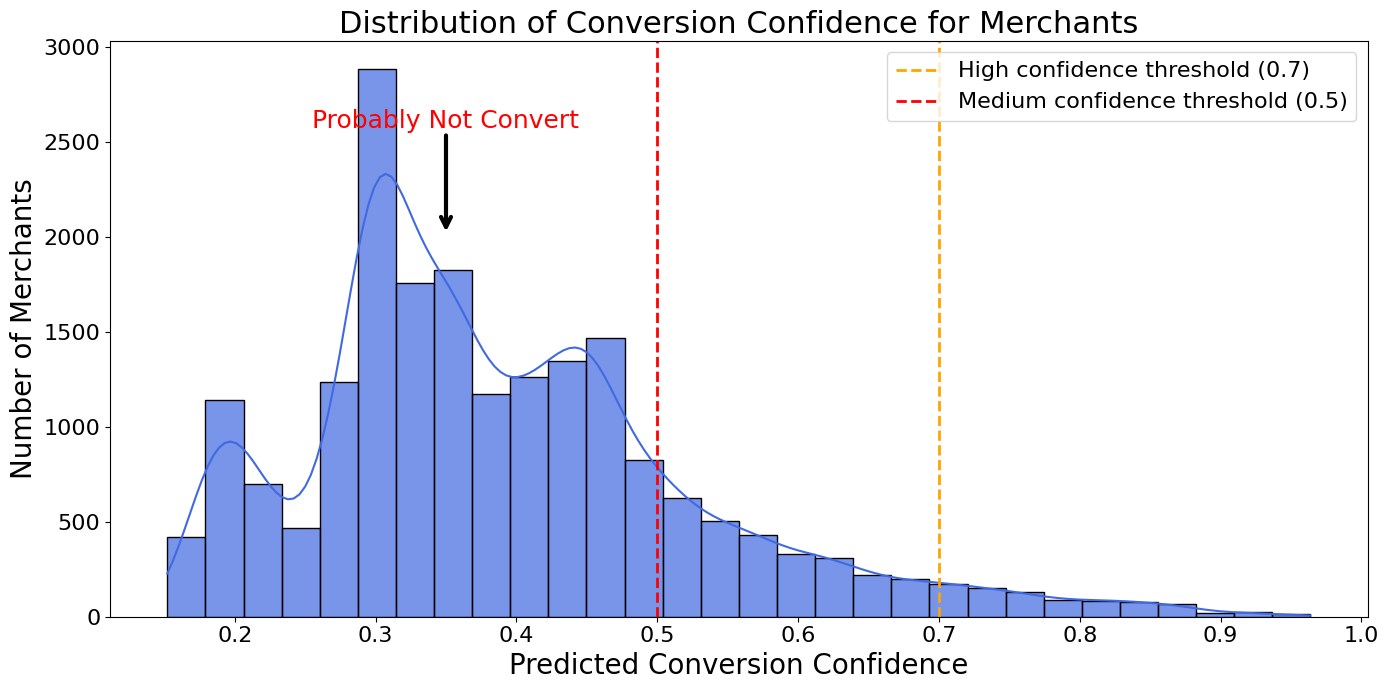

In [26]:
import matplotlib.pyplot as plt

import seaborn as sns

plt.figure(figsize=(14, 7))
sns.histplot(
    confidence_with_volume_sorted['Confidence'], 
    bins=30, 
    kde=True, 
    color='royalblue', 
    alpha=0.7
)

plt.axvline(0.7, color='orange', linestyle='--', linewidth=2, label='High confidence threshold (0.7)')
plt.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Medium confidence threshold (0.5)')

# Place arrow and text in the area spanning 0.0 to 0.5
midpoint = 0.35
y_max = plt.gca().get_ylim()[1]
plt.annotate(
    'Probably Not Convert', 
    xy=(midpoint, y_max*0.65), 
    xytext=(midpoint, y_max*0.85),
    arrowprops=dict(facecolor='red', arrowstyle='->', lw=3, shrinkA=0, shrinkB=8),
    fontsize=18, 
    color='red',
    horizontalalignment='center'
)

plt.title('Distribution of Conversion Confidence for Merchants', fontsize=22)
plt.xlabel('Predicted Conversion Confidence', fontsize=20)
plt.ylabel('Number of Merchants', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('confidence_distribution.pdf')
plt.show()



# Transformer Based classifier

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader


# ── Dataset (unchanged) ────────────────────────────────────────────────────────

class MerchantDataset(Dataset):
    def __init__(self, series_list, labels, max_len=None):
        self.max_len = max_len or max(len(s) for s in series_list)
        self.series  = series_list
        self.labels  = labels

    def __len__(self):
        return len(self.series)

    def __getitem__(self, idx):
        s   = np.array(self.series[idx], dtype=np.float32)
        L   = len(s)
        pad = self.max_len - L
        s_padded = np.concatenate([s, np.zeros(pad, dtype=np.float32)])
        mask     = np.array([False] * L + [True] * pad, dtype=bool)
        return (
            torch.tensor(s_padded).unsqueeze(-1),
            torch.tensor(mask),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


# ── 1. Multi-scale periodic positional encoding ────────────────────────────────
#
# Standard learned embeddings have no notion of periodicity.
# We explicitly encode known subscription-relevant cycles:
#   - day of week  (period=7)
#   - biweekly     (period=14)
#   - monthly      (period=30)
#   - quarterly    (period=90)
# Each period contributes a (sin, cos) pair → the model can learn
# "position 37 is a Monday AND day 7 of the month" simultaneously.

class PeriodicPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000, periods=(7, 14, 30, 90)):
        super().__init__()
        self.periods = periods
        # Number of sin/cos pairs = len(periods)
        # We project them up to d_model
        n_periodic = len(periods) * 2          # sin+cos per period
        self.proj  = nn.Linear(n_periodic + 1, d_model)  # +1 for raw position

        # Precompute fixed sin/cos table — not learnable, purely structural
        pe = torch.zeros(max_len, n_periodic + 1)
        positions = torch.arange(max_len).float()
        pe[:, 0] = positions / max_len          # normalized raw position
        for i, p in enumerate(periods):
            pe[:, 1 + 2*i]     = torch.sin(2 * torch.pi * positions / p)
            pe[:, 1 + 2*i + 1] = torch.cos(2 * torch.pi * positions / p)
        self.register_buffer('pe', pe)          # (max_len, n_periodic+1)

    def forward(self, x):
        """x: (B, T, d_model) — adds periodic position signal"""
        T = x.size(1)
        pos_features = self.pe[:T].unsqueeze(0)         # (1, T, n_periodic+1)
        pos_embedded = self.proj(pos_features)           # (1, T, d_model)
        return x + pos_embedded


# ── 2. Multi-scale temporal convolution front-end ──────────────────────────────
#
# Before the transformer sees anything, we run 1D convolutions at
# kernel sizes matching our periods of interest (7, 14, 30 days).
# This gives the transformer pre-extracted local periodic features
# rather than asking attention to discover them from raw scalars.
# Each kernel acts like a local moving average / pattern detector.
# Outputs are concatenated then projected back to d_model.

class MultiScaleTemporalConv(nn.Module):
    def __init__(self, in_channels, d_model, kernels=(7, 14, 30)):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels, d_model // len(kernels),
                          kernel_size=k, padding=k // 2),
                nn.GELU(),
                nn.BatchNorm1d(d_model // len(kernels))
            )
            for k in kernels
        ])
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        """x: (B, T, 1) → (B, T, d_model)"""
        T   = x.size(1)                        # original sequence length
        x_t = x.transpose(1, 2)               # (B, 1, T)
        features = []
        for conv in self.convs:
            out = conv(x_t)                    # (B, d_model//n_kernels, T or T±1)
            out = out[:, :, :T]                # trim to exactly T — fixes the mismatch
            features.append(out)
        x_t = torch.cat(features, dim=1)       # (B, d_model, T)
        x   = x_t.transpose(1, 2)             # (B, T, d_model)
        return self.proj(x)

# ── 3. Relative position bias in attention ─────────────────────────────────────
#
# Standard attention computes Q·Kᵀ with no knowledge of distance between tokens.
# We add a learned scalar bias that depends on the relative lag between positions.
# This means the model can learn "positions 30 days apart should attend more
# strongly" — directly encoding the autocorrelation structure.
#
# We bucket lags to keep the bias table manageable:
#   exact lags 0..max_exact are kept as-is
#   larger lags are log-bucketed (many lags → fewer buckets)

class RelativePositionBias(nn.Module):
    def __init__(self, num_heads, max_exact=64, num_buckets=128):
        super().__init__()
        self.num_heads  = num_heads
        self.max_exact  = max_exact
        self.num_buckets = num_buckets
        # One learned bias value per (head, bucket)
        self.bias_table = nn.Embedding(num_buckets, num_heads)
        nn.init.zeros_(self.bias_table.weight)

    def _lag_to_bucket(self, lags):
        """Map relative lag tensor to bucket indices."""
        abs_lags   = lags.abs()
        is_small   = abs_lags < self.max_exact
        # Log-scale bucketing for larger lags
        log_bucket = (
            torch.log(abs_lags.float().clamp(min=1) / self.max_exact)
            / torch.log(torch.tensor(self.num_buckets / self.max_exact))
            * (self.num_buckets - self.max_exact)
        ).long().clamp(0, self.num_buckets - self.max_exact - 1)
        bucket = torch.where(is_small, abs_lags, self.max_exact + log_bucket)
        return bucket.clamp(0, self.num_buckets - 1)

    def forward(self, seq_len, device):
        """Returns bias of shape (num_heads, seq_len, seq_len)"""
        positions = torch.arange(seq_len, device=device)
        lags      = positions.unsqueeze(0) - positions.unsqueeze(1)  # (T, T)
        buckets   = self._lag_to_bucket(lags)                        # (T, T)
        bias      = self.bias_table(buckets)                         # (T, T, heads)
        return bias.permute(2, 0, 1)                                 # (heads, T, T)


# ── 4. Transformer encoder layer with relative position bias ───────────────────
#
# PyTorch's built-in TransformerEncoderLayer doesn't expose the attention
# logits for bias injection, so we write a minimal custom layer.
# Everything else (FFN, LayerNorm, dropout) is identical to the standard layer.

class PeriodicTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout, rel_pos_bias):
        super().__init__()
        self.nhead      = nhead
        self.d_head     = d_model // nhead
        self.rel_pos    = rel_pos_bias

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        """
        x:            (B, T, d_model)
        padding_mask: (B, T) True = padded
        """
        B, T, D = x.shape
        H, Dh   = self.nhead, self.d_head

        # Multi-head projections
        Q = self.q_proj(x).view(B, T, H, Dh).transpose(1, 2)  # (B, H, T, Dh)
        K = self.k_proj(x).view(B, T, H, Dh).transpose(1, 2)
        V = self.v_proj(x).view(B, T, H, Dh).transpose(1, 2)

        # Attention scores
        scores = (Q @ K.transpose(-2, -1)) / (Dh ** 0.5)       # (B, H, T, T)

        # Add relative position bias — this is where periodicity awareness lives
        rel_bias = self.rel_pos(T, x.device)                    # (H, T, T)
        scores   = scores + rel_bias.unsqueeze(0)               # (B, H, T, T)

        # Mask padded positions
        if padding_mask is not None:
            # (B, 1, 1, T) broadcast across heads and query positions
            scores = scores.masked_fill(
                padding_mask.unsqueeze(1).unsqueeze(2), float('-inf')
            )

        attn   = F.softmax(scores, dim=-1)
        attn   = self.dropout(attn)
        out    = (attn @ V).transpose(1, 2).contiguous().view(B, T, D)
        out    = self.o_proj(out)

        # Pre-norm residual connections (more stable than post-norm)
        x = self.norm1(x + self.dropout(out))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


# ── 5. Full model ──────────────────────────────────────────────────────────────

class PeriodicMerchantTransformer(nn.Module):
    """
    Transformer encoder designed for merchant subscription detection.

    Key design decisions vs. the vanilla transformer:
      1. Multi-scale conv front-end extracts 7/14/30-day local patterns first
      2. Periodic positional encoding explicitly encodes known billing cycles
      3. Relative position bias lets attention learn lag-specific weights
      4. Masked average pooling ignores padded positions in the final embedding
    """
    def __init__(self, d_model=64, nhead=4, num_layers=3, dim_ff=256,
                 dropout=0.1, max_len=2000, num_classes=2,
                 conv_kernels=(7, 14, 30),
                 periods=(7, 14, 30, 90)):
        super().__init__()

        # Step 1: extract multi-scale local features
        self.temporal_conv = MultiScaleTemporalConv(
            in_channels=1, d_model=d_model, kernels=conv_kernels
        )

        # Step 2: add periodic positional information
        self.pos_encoding = PeriodicPositionalEncoding(
            d_model=d_model, max_len=max_len, periods=periods
        )

        # Shared relative position bias across all layers (parameter efficient)
        rel_pos_bias = RelativePositionBias(
            num_heads=nhead, max_exact=64, num_buckets=128
        )

        # Step 3: stack transformer layers with relative position bias
        self.layers = nn.ModuleList([
            PeriodicTransformerLayer(d_model, nhead, dim_ff, dropout, rel_pos_bias)
            for _ in range(num_layers)
        ])

        # Step 4: classify from masked-pooled embedding
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def _masked_pool(self, x, padding_mask):
        """Average pool over real (non-padded) timesteps only."""
        real = (~padding_mask).float().unsqueeze(-1)         # (B, T, 1)
        return (x * real).sum(1) / real.sum(1).clamp(min=1)  # (B, d_model)

    def forward(self, x, padding_mask):
        x = self.temporal_conv(x)       # (B, T, d_model)
        x = self.pos_encoding(x)        # (B, T, d_model)
        for layer in self.layers:
            x = layer(x, padding_mask)  # (B, T, d_model)
        return self.classifier(self._masked_pool(x, padding_mask))

    def get_embedding(self, x, padding_mask):
        x = self.temporal_conv(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, padding_mask)
        return self._masked_pool(x, padding_mask)

In [36]:
# Builds each merchant's series from their OWN active window only.
# No global date alignment, no dishonest leading zeros.

label_map = {'subscription': 1, 'non-subscription': 0}

def get_raw_series(group, date_col='date', value_col='total_volume'):
    """
    Daily volume over the merchant's own tenure window only.
    Zeros within the window = real gaps (honest signal).
    Zeros before first charge = don't exist (never injected).
    """
    group = group.sort_values(date_col).copy()
    group[date_col] = pd.to_datetime(group[date_col])
    s = group.set_index(date_col)[value_col].resample('D').sum()

    s_min, s_max = s.min(), s.max()
    if s_max > s_min:
        s = (s - s_min) / (s_max - s_min)
    else:
        s = s * 0.0

    return s.values.astype(np.float32)


# Build raw series for every merchant — do this once
merchant_raw_series = {}
for merchant_id, group in total_df.groupby('merchant'):
    merchant_raw_series[merchant_id] = get_raw_series(group)

lengths = [len(v) for v in merchant_raw_series.values()]
print(f"Lengths — min: {min(lengths)}, max: {max(lengths)}, "
      f"mean: {np.mean(lengths):.0f}, median: {np.median(lengths):.0f}")


def get_series_for_merchants(merchant_list, labels_list):
    series_out, labels_out, valid_merchants = [], [], []
    for m, lbl in zip(merchant_list, labels_list):
        if m in merchant_raw_series:
            series_out.append(merchant_raw_series[m])
            labels_out.append(label_map[lbl])
            valid_merchants.append(m)
    return series_out, labels_out, valid_merchants


# Reuse your existing split indices from the notebook
train_merchants_raw = np.concatenate([m_subscripted[indices_sub_train], m_unknown[indices_non_sub_train]])
train_labels_raw    = np.concatenate([y_subscripted[indices_sub_train], y_unknown[indices_non_sub_train]])
test_merchants_raw  = np.concatenate([m_subscripted[indices_sub_test],  m_unknown[indices_non_sub_test]])
test_labels_raw     = np.concatenate([y_subscripted[indices_sub_test],  y_unknown[indices_non_sub_test]])

train_series, train_int_labels, train_merchants_valid = get_series_for_merchants(train_merchants_raw, train_labels_raw)
test_series,  test_int_labels,  test_merchants_valid  = get_series_for_merchants(test_merchants_raw,  test_labels_raw)

# Max len = longest individual merchant tenure, not the global date span
MAX_LEN = max(len(s) for s in merchant_raw_series.values())

train_dataset = MerchantDataset(train_series, train_int_labels, max_len=MAX_LEN)
test_dataset  = MerchantDataset(test_series,  test_int_labels,  max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)} | MAX_LEN: {MAX_LEN}")

Lengths — min: 1, max: 418, mean: 216, median: 225
Train: 9361 | Test: 4013 | MAX_LEN: 418


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Replace the old TimeSeriesTransformer(...) line with:
model = PeriodicMerchantTransformer(
    d_model=64,
    nhead=4,
    num_layers=3,
    dim_ff=256,
    dropout=0.1,
    max_len=MAX_LEN + 10,
    num_classes=2,
    conv_kernels=(7, 14, 30),   # matches your weekly/biweekly/monthly features
    periods=(7, 14, 30, 90)     # explicitly encoded billing cycles
).to(device)

# Mirror your RF class weighting — subscription is the minority class
class_weights = torch.tensor([1.0, 6.0], device=device)
criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, mask, y in loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(x, mask)
            loss   = criterion(logits, y)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total


EPOCHS = 60
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    test_loss,  test_acc  = run_epoch(test_loader,  training=False)
    scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"Train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"Test  loss {test_loss:.4f} acc {test_acc:.3f}")

In [31]:
def extract_embeddings(merchant_list):
    """
    Returns transformer embeddings (shape: n_merchants x d_model)
    for any list of merchant IDs, using raw series (no dishonest padding).
    """
    series = []
    for m in merchant_list:
        if m in merchant_raw_series:
            series.append(merchant_raw_series[m])
        else:
            # Merchant missing from data — use empty series, mask will cover it
            series.append(np.zeros(1, dtype=np.float32))

    dataset    = MerchantDataset(series, [0] * len(series), max_len=MAX_LEN)
    loader     = DataLoader(dataset, batch_size=64, shuffle=False)
    embeddings = []

    model.eval()
    with torch.no_grad():
        for x, mask, _ in loader:
            emb = model.get_embedding(x.to(device), mask.to(device))
            embeddings.append(emb.cpu().numpy())

    return np.vstack(embeddings)


train_emb = extract_embeddings(train_merchants_valid)
test_emb  = extract_embeddings(test_merchants_valid)

# Option A — transformer embeddings alone
x_train_transformer = train_emb
x_test_transformer  = test_emb

# Option B — concatenate with your hand-crafted features (usually better)
x_train_combined = np.concatenate([x_train, train_emb], axis=1)
x_test_combined  = np.concatenate([x_test,  test_emb],  axis=1)

print(f"Embedding shape:  {train_emb.shape}")         # (n, 64)
print(f"Combined shape:   {x_train_combined.shape}")  # (n, 19+64)

# Drop into your existing RandomForest
from sklearn.ensemble import RandomForestClassifier

rf_transformer = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    random_state=42,
    class_weight={'subscription': 5, 'non-subscription': 1}
)
rf_transformer.fit(x_train_combined, y_train)

print("Test accuracy (hand-crafted + transformer embeddings):",
      rf_transformer.score(x_test_combined, y_test))

Embedding shape:  (9361, 64)
Combined shape:   (9361, 83)
Test accuracy (hand-crafted + transformer embeddings): 0.7866932469474209


# SAX model

In [33]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin

class SAXTransformer(BaseEstimator, TransformerMixin):
    """
    Converts a variable-length time series into a fixed-size feature vector
    using Symbolic Aggregate approXimation (SAX).

    Steps:
      1. PAA (Piecewise Aggregate Approximation): divide series into n_segments
         windows, replace each with its mean → smoothed, fixed-length rep
      2. Symbolization: map each PAA value to a letter a–z using breakpoints
         derived from a standard normal distribution (equiprobable regions)
      3. Bag of Words: count unigram and bigram symbol frequencies → fixed vector

    Why this works for variable-length series:
      - PAA always produces n_segments values regardless of input length
      - The symbol histogram is always alphabet_size + alphabet_size^2 long
      - No padding, no masking, no false zeros
    """
    def __init__(self, n_segments=20, alphabet_size=5, use_bigrams=True):
        assert 2 <= alphabet_size <= 26, "alphabet_size must be between 2 and 26"
        self.n_segments   = n_segments
        self.alphabet_size = alphabet_size
        self.use_bigrams  = use_bigrams

        # Breakpoints for equiprobable regions under N(0,1)
        # e.g. alphabet_size=4 → 3 breakpoints dividing N(0,1) into 4 equal areas
        self.breakpoints = norm.ppf(
            np.linspace(0, 1, alphabet_size + 1)[1:-1]
        )
        self.letters = [chr(ord('a') + i) for i in range(alphabet_size)]

    def _paa(self, series):
        """Piecewise Aggregate Approximation — splits series into n_segments windows."""
        n = len(series)
        if n == 0:
            return np.zeros(self.n_segments)
        if n < self.n_segments:
            # Series shorter than n_segments: repeat-interpolate
            indices = np.linspace(0, n - 1, self.n_segments)
            return np.interp(indices, np.arange(n), series)
        # General case: average each window
        segments = np.array_split(series, self.n_segments)
        return np.array([seg.mean() for seg in segments])

    def _normalize(self, series):
        """Z-normalize: mean=0, std=1. Required before applying SAX breakpoints."""
        s = np.array(series, dtype=np.float32)
        mu, std = s.mean(), s.std()
        if std < 1e-6:
            return np.zeros_like(s)
        return (s - mu) / std

    def _to_symbols(self, paa_values):
        """Map each PAA value to a letter using breakpoint lookup."""
        symbols = []
        for val in paa_values:
            # Find which region the value falls in
            idx = np.searchsorted(self.breakpoints, val)
            symbols.append(self.letters[idx])
        return symbols

    def _to_bow(self, symbols):
        """
        Bag-of-words over unigrams + bigrams.
        Always returns a fixed-length vector regardless of series length.
        """
        vocab_unigrams = self.letters
        vocab_bigrams  = [a + b for a in self.letters for b in self.letters]

        unigram_counts = Counter(symbols)
        bigram_counts  = Counter(
            symbols[i] + symbols[i+1] for i in range(len(symbols) - 1)
        ) if self.use_bigrams else {}

        total = len(symbols)
        unigram_vec = np.array(
            [unigram_counts.get(u, 0) / total for u in vocab_unigrams],
            dtype=np.float32
        )
        if self.use_bigrams:
            bigram_vec = np.array(
                [bigram_counts.get(b, 0) / max(total - 1, 1) for b in vocab_bigrams],
                dtype=np.float32
            )
            return np.concatenate([unigram_vec, bigram_vec])
        return unigram_vec

    def transform_one(self, series):
        """Full SAX pipeline for a single series."""
        series    = self._normalize(series)
        paa       = self._paa(series)
        symbols   = self._to_symbols(paa)
        return self._to_bow(symbols)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """X: list of 1D numpy arrays of variable length."""
        return np.array([self.transform_one(s) for s in X])

    @property
    def feature_dim(self):
        n = self.alphabet_size
        return n + n**2 if self.use_bigrams else n

In [34]:
# Uses merchant_raw_series built in the transformer Cell 2
# Plug in after your feature_extracted is already defined

sax = SAXTransformer(
    n_segments=20,    # number of PAA windows — tune this
    alphabet_size=5,  # a–e symbols; 5 gives a good balance
    use_bigrams=True  # captures transition patterns e.g. 'ab', 'cc'
)

print(f"SAX feature vector size: {sax.feature_dim}")
# alphabet_size=5, bigrams=True → 5 + 25 = 30 features per merchant

# Build SAX features aligned to your existing merchant splits
def get_sax_features(merchant_list):
    series = []
    for m in merchant_list:
        if m in merchant_raw_series:
            series.append(merchant_raw_series[m])
        else:
            series.append(np.zeros(1, dtype=np.float32))
    return sax.transform(series)

train_sax = get_sax_features(
    np.concatenate([m_subscripted[indices_sub_train], m_unknown[indices_non_sub_train]])
)
test_sax = get_sax_features(
    np.concatenate([m_subscripted[indices_sub_test], m_unknown[indices_non_sub_test]])
)

print(f"SAX train shape: {train_sax.shape}")   # (n_train, 30)
print(f"SAX test shape:  {test_sax.shape}")    # (n_test,  30)

# Three options to try:
# Option A — SAX alone
x_train_sax = train_sax
x_test_sax  = test_sax

# Option B — hand-crafted + SAX (recommended first try)
x_train_sax_combined = np.concatenate([x_train, train_sax], axis=1)
x_test_sax_combined  = np.concatenate([x_test,  test_sax],  axis=1)

# Option C — hand-crafted + SAX + transformer embeddings (kitchen sink)
x_train_all = np.concatenate([x_train, train_sax, train_emb], axis=1)
x_test_all  = np.concatenate([x_test,  test_sax,  test_emb],  axis=1)

print(f"Hand-crafted only:          {x_train.shape[1]} features")
print(f"SAX only:                   {train_sax.shape[1]} features")
print(f"Hand-crafted + SAX:         {x_train_sax_combined.shape[1]} features")
print(f"Hand-crafted + SAX + Trans: {x_train_all.shape[1]} features")

SAX feature vector size: 30
SAX train shape: (9361, 30)
SAX test shape:  (4013, 30)
Hand-crafted only:          19 features
SAX only:                   30 features
Hand-crafted + SAX:         49 features
Hand-crafted + SAX + Trans: 113 features


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings

configs = {
    "Hand-crafted only":           (x_train,              x_test),
    "SAX only":                    (x_train_sax,          x_test_sax),
    "Hand-crafted + SAX":          (x_train_sax_combined, x_test_sax_combined),
    "Hand-crafted + SAX + Trans":  (x_train_all,          x_test_all),
}

for name, (X_tr, X_te) in configs.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf = RandomForestClassifier(
            n_estimators=150,
            max_depth=5,
            random_state=42,
            class_weight={'subscription': 5, 'non-subscription': 1}
        )
        clf.fit(X_tr, y_train)
        acc = clf.score(X_te, y_test)
        print(f"{name:<35} → test acc: {acc:.4f}  | n_features: {X_tr.shape[1]}")

Hand-crafted only                   → test acc: 0.7919  | n_features: 19
SAX only                            → test acc: 0.5074  | n_features: 30
Hand-crafted + SAX                  → test acc: 0.7887  | n_features: 49
Hand-crafted + SAX + Trans          → test acc: 0.7874  | n_features: 113
